<a href="https://colab.research.google.com/github/Davemtz192/devops-aws-fase1/blob/main/Actvidad_4_punto_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio Práctico: Búsqueda Cuántica con el Algoritmo de Grover

El Algoritmo de Grover es uno de los pilares de la computación cuántica. Clásicamente, buscar un elemento específico en una base de datos no estructurada de $N$ elementos requiere, en promedio, $N/2$ intentos. El algoritmo de Grover logra esto en aproximadamente $\sqrt{N}$ pasos, ofreciendo una **aceleración cuadrática**.

Más allá de la búsqueda, la técnica subyacente se conoce como **Amplificación de Amplitud**, un bloque fundamental para el diseño posterior de algoritmos en Machine Learning Cuántico (QML) y procesos de optimización.

## 1. Instalación y Preparación del Entorno

Para este laboratorio, se utilizará la versión más reciente de Qiskit (1.0+), aprovechando las Primitivas V2 para la ejecución simulada de los circuitos propuestos.

In [1]:
# Instalación de las librerías necesarias. Si ya se encuentran instaladas en el entorno, este comando puede omitirse.
!pip install 'qiskit>=1.0.0' 'qiskit-aer' 'matplotlib' 'pylatexenc'

import math
from qiskit import QuantumCircuit
from qiskit.circuit.library import GroverOperator
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram

print("Librerías importadas correctamente.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.7 MB/s eta 0:00:00
Librerías importadas correctamente.


## 2. Construcción Modular del Algoritmo

Para comprender el diseño del algoritmo de Grover, resulta útil conceptualizarlo en tres componentes principales:
1. **Superposición Uniforme:** Se aplican compuertas Hadamard ($H$) a todos los qubits iniciales para explorar el espacio de búsqueda completo de forma simultánea.
2. **El Oráculo:** Funciona como una "caja negra" que identifica el estado buscado y voltea su fase (multiplica su amplitud de probabilidad por -1).
3. **El Difusor (Operador de Grover):** Es el mecanismo que amplifica la probabilidad de medir el estado marcado por el oráculo, suprimiendo simultáneamente las demás probabilidades.

A continuación, se definirán funciones genéricas para automatizar la construcción de este circuito, independientemente de la cantidad de qubits que se decidan utilizar.

In [2]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import GroverOperator, Diagonal # Se añade la importación de Diagonal

def crear_oraculo(n_qubits, estado_objetivo):
    """
    Crea un oráculo cuántico que invierte la fase de un estado binario específico.
    """
    qc = QuantumCircuit(n_qubits)

    # Se inicializa un arreglo donde todas las fases son 1
    estados = [1] * (2**n_qubits)

    # Se invierte la fase (-1) únicamente para el índice que coincide con el estado objetivo
    indice_objetivo = int(estado_objetivo, 2)
    estados[indice_objetivo] = -1

    # Se instancia la matriz diagonal y se anexa al circuito
    oraculo_diagonal = Diagonal(estados)
    qc.append(oraculo_diagonal, range(n_qubits))

    return qc

def ensamblar_circuito_grover(n_qubits, estado_objetivo, iteraciones):
    """
    Ensambla el circuito completo de Grover.
    """
    qc = QuantumCircuit(n_qubits)

    # 1. Preparación del estado inicial en superposición uniforme
    qc.h(range(n_qubits))

    # 2. Aplicación iterativa del Oráculo y el Difusor
    if iteraciones > 0:
        oraculo = crear_oraculo(n_qubits, estado_objetivo)
        # GroverOperator automatiza la creación del difusor basándose en el oráculo provisto
        operador_grover = GroverOperator(oraculo)
        qc.compose(operador_grover.power(iteraciones), inplace=True)

    # 3. Medición final para colapsar el estado
    qc.measure_all()
    return qc

## 3. Experimentación y Visualización de la Interferencia

El funcionamiento del cómputo cuántico se fundamenta en la interferencia de ondas de probabilidad. Para demostrar este principio físico, se ejecutará una búsqueda de un estado específico dentro de un sistema de múltiples qubits.

El número óptimo de iteraciones $t$ para maximizar la probabilidad de encontrar el estado objetivo se rige por la siguiente aproximación matemática, donde $N = 2^n$:

$$t \approx \lfloor \frac{\pi}{4} \sqrt{N} \rfloor$$

En el siguiente bloque, se evaluará la distribución de probabilidades **antes** de aplicar el difusor de Grover (estado de pura superposición) y **después** de aplicar las iteraciones óptimas calculadas.

Espacio de búsqueda total: 64 combinaciones posibles.
Buscando el estado marcado: |101010⟩
Iteraciones óptimas de Grover calculadas: 6
--------------------------------------------------
Arquitectura del Circuito Cuántico (Aplicando Grover):


/tmp/ipykernel_4593/3367838784.py:18: DeprecationWarning: The class ``qiskit.circuit.library.generalized_gates.diagonal.Diagonal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use DiagonalGate instead.
  oraculo_diagonal = Diagonal(estados)
/tmp/ipykernel_4593/3367838784.py:36: DeprecationWarning: The class ``qiskit.circuit.library.grover_operator.GroverOperator`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use qiskit.circuit.library.grover_operator instead.
  operador_grover = GroverOperator(oraculo)


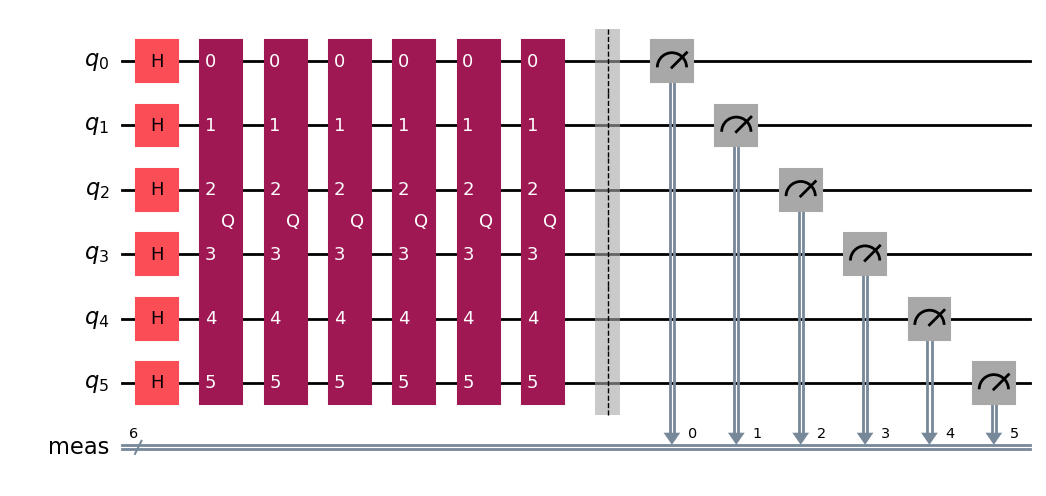

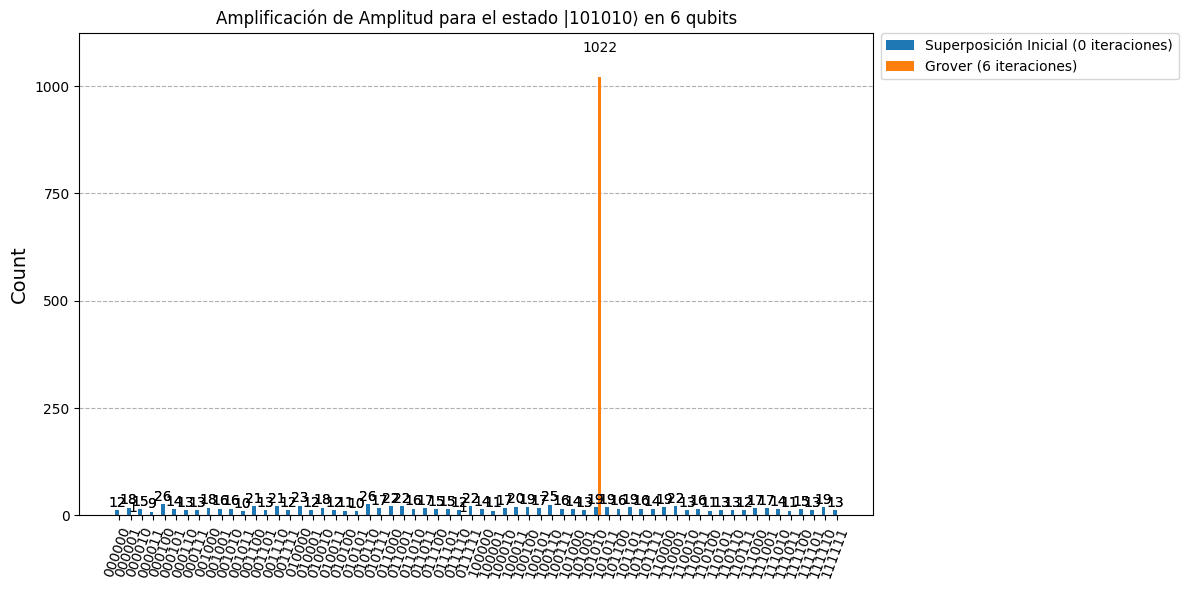

In [6]:
# ==========================================
# PARÁMETROS DEL EXPERIMENTO
# Se recomienda al alumno modificar estos valores para observar distintos comportamientos.
# ==========================================
n_qubits = 6
estado_objetivo = "101010" # La longitud de esta cadena binaria debe coincidir con n_qubits

# Cálculo del espacio de búsqueda (N) y las iteraciones teóricas óptimas
N = 2**n_qubits
iteraciones_optimas = math.floor(math.pi / 4 * math.sqrt(N / 1))

print(f"Espacio de búsqueda total: {N} combinaciones posibles.")
print(f"Buscando el estado marcado: |{estado_objetivo}⟩")
print(f"Iteraciones óptimas de Grover calculadas: {iteraciones_optimas}")
print("-" * 50)

# Se instancian dos circuitos distintos para fines comparativos
circuito_sin_grover = ensamblar_circuito_grover(n_qubits, estado_objetivo, iteraciones=0)
circuito_con_grover = ensamblar_circuito_grover(n_qubits, estado_objetivo, iteraciones=iteraciones_optimas)

# ==========================================
# VISUALIZACIÓN DEL CIRCUITO
# ==========================================
print("Arquitectura del Circuito Cuántico (Aplicando Grover):")
# En Jupyter Notebook, display() permite renderizar la imagen a mitad de la celda
display(circuito_con_grover.draw(output='mpl'))

# ==========================================
# EJECUCIÓN Y EXTRACCIÓN DE RESULTADOS
# ==========================================
# Ejecución a través del simulador StatevectorSampler (Primitivas V2)
sampler = StatevectorSampler()
job_sin = sampler.run([(circuito_sin_grover,)])
job_con = sampler.run([(circuito_con_grover,)])

# Extracción de los conteos desde el registro clásico
conteos_sin_grover = job_sin.result()[0].data.meas.get_counts()
conteos_con_grover = job_con.result()[0].data.meas.get_counts()

# Visualización gráfica de los resultados obtenidos
plot_histogram(
    [conteos_sin_grover, conteos_con_grover],
    legend=['Superposición Inicial (0 iteraciones)', f'Grover ({iteraciones_optimas} iteraciones)'],
    title=f"Amplificación de Amplitud para el estado |{estado_objetivo}⟩ en {n_qubits} qubits",
    figsize=(12, 6),
    color=['#1f77b4', '#ff7f0e']
)

### Interpretación de Resultados

Al analizar el histograma generado, se evidencian dos estados físicos del sistema:
* **Barra Azul:** Representa el registro antes de aplicar el algoritmo. El estado objetivo posee la misma probabilidad de ser medido que cualquier otra combinación del espacio de Hilbert (probabilidad uniforme).
* **Barra Naranja:** Tras ejecutar el operador de Grover el número óptimo de veces, la función de onda colapsa de forma constructiva hacia el estado objetivo $|1011\rangle$, alcanzando una probabilidad cercana al **100%**. De manera simultánea, las demás probabilidades se atenúan drásticamente por interferencia destructiva.

### Reto Práctico
¿Qué sucede con el sistema cuántico si se aplica el operador de Grover *más* veces de las teóricamente óptimas?

Se sugiere modificar la variable `iteraciones_optimas` en la celda de código anterior, sumando 2 o 3 iteraciones adicionales al valor calculado. Al ejecutar nuevamente la celda y observar el nuevo histograma, se manifestará el fenómeno físico conocido como **sobre-rotación** del estado cuántico.